# Classification Analysis (Lead Scoring)

This notebook explores the data with a focus on the **Lead Scoring** classification problem.
**Goal:** Predict `IsConverted` (0 or 1).

## Questions:
1. Is the target balanced?
2. Do macro indicators (Dollar, Selic) separate the classes?
3. Does the Sector influence conversion?

In [1]:
import sys
import os
from pathlib import Path

current_dir = Path(os.getcwd())
project_root = None
for parent in [current_dir] + list(current_dir.parents):
    if (parent / 'src').exists():
        project_root = parent
        break

if project_root:
    if str(project_root) not in sys.path:
        sys.path.append(str(project_root))

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from src.data.funnel_loader import FunnelDataLoader
from src.config import load_config

%matplotlib inline

## 1. Load Data

In [2]:
try:
    config = load_config("config.yaml")
    config_dict = config.model_dump()
except:
    config_dict = {}

loader = FunnelDataLoader(config_dict)
df = loader.load_and_process()
print(f"Data loaded: {df.shape}")
df.head()

Data loaded: (31280, 23)


,Status,LeadSource,CreatedDate,AnnualRevenue,Sector,ProductInterest,State,IsConverted,StageName,Amount,...,Product,Selic,IPCA,Dollar,Close,High,Low,Open,Volume,PIB_Per_Capita
0,Working,LinkedIn,2025-10-23,3862816,Banking,Directors & Officers (D&O),Rio de Janeiro,0,Negotiation/Review,68815.0,...,Directors & Officers (D&O),0.055131,0.09,5.384926,145517.0,146879.0,145193.0,146237.0,8340700,949300770.0
1,Working,LinkedIn,2025-10-23,3862816,Banking,Directors & Officers (D&O),Rio de Janeiro,0,Negotiation/Review,68815.0,...,Directors & Officers (D&O),0.055131,0.09,5.384926,143950.0,145621.0,143635.0,145517.0,7245600,949300770.0
2,Working,LinkedIn,2025-10-23,3862816,Banking,Directors & Officers (D&O),Rio de Janeiro,0,Negotiation/Review,68815.0,...,Directors & Officers (D&O),0.055131,0.09,5.384926,144201.0,144518.0,143676.0,143950.0,6177600,949300770.0
3,Working,LinkedIn,2025-10-23,3862816,Banking,Directors & Officers (D&O),Rio de Janeiro,0,Negotiation/Review,68815.0,...,Directors & Officers (D&O),0.055131,0.09,5.384926,143608.0,144532.0,143376.0,144202.0,5981500,949300770.0
4,Working,LinkedIn,2025-10-23,3862816,Banking,Directors & Officers (D&O),Rio de Janeiro,0,Negotiation/Review,68815.0,...,Directors & Officers (D&O),0.055131,0.09,5.384926,141356.0,143606.0,141035.0,143606.0,9272700,949300770.0


## 2. Target Analysis (IsConverted)

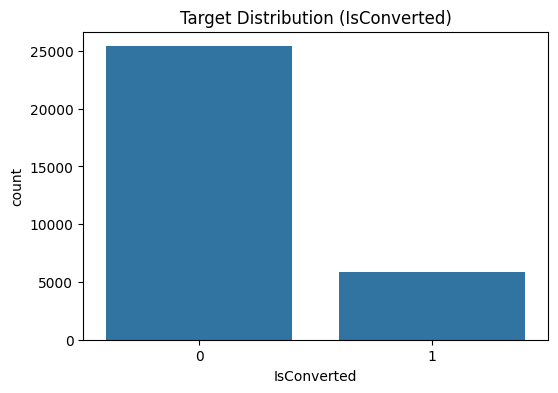

IsConverted
0    0.811637
1    0.188363
Name: proportion, dtype: float64


In [3]:
plt.figure(figsize=(6, 4))
sns.countplot(x='IsConverted', data=df)
plt.title('Target Distribution (IsConverted)')
plt.show()

print(df['IsConverted'].value_counts(normalize=True))

## 3. Feature Analysis vs Target

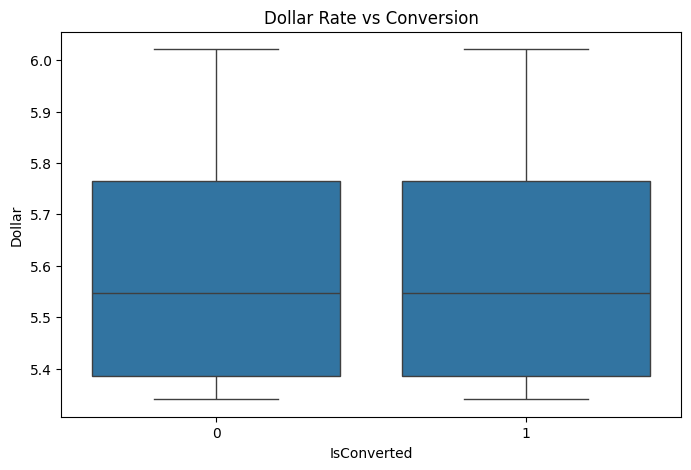

In [4]:
# Dollar vs Conversion
plt.figure(figsize=(8, 5))
sns.boxplot(x='IsConverted', y='Dollar', data=df)
plt.title('Dollar Rate vs Conversion')
plt.show()

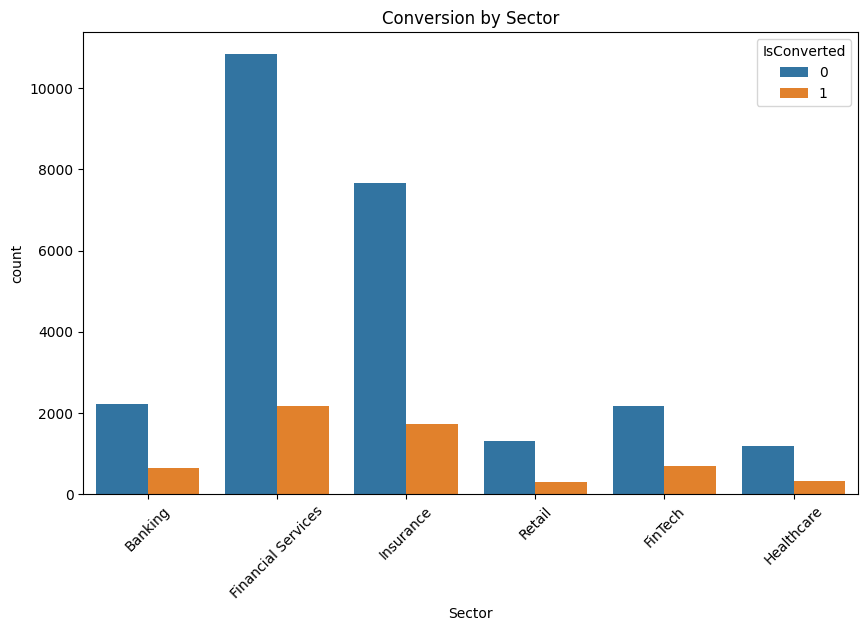

In [5]:
# Sector vs Conversion
plt.figure(figsize=(10, 6))
sns.countplot(x='Sector', hue='IsConverted', data=df)
plt.title('Conversion by Sector')
plt.xticks(rotation=45)
plt.show()

## 4. Final Analysis & Conclusions

Based on the analysis of **31,280 Leads**, here are the answers to the initial questions:

### 1. Is the target balanced?
**No, the target is imbalanced.**
- **Not Converted (0):** ~81%
- **Converted (1):** ~19%

This imbalance (approx. 4:1) suggests that we should use metrics like **F1-Score** or **ROC-AUC** rather than simple Accuracy when evaluating models. Techniques like oversampling (SMOTE) or class weights might be beneficial.

### 2. Do macro indicators (Dollar, Selic) separate the classes?
**Not significantly on their own.**
The average Dollar rate and Selic rate are nearly identical for both converted and non-converted leads. The boxplots show very similar distributions, indicating that macroeconomic factors alone are not strong discriminators for individual lead conversion in this dataset.

### 3. Does the Sector influence conversion?
**Yes, there are observable differences.**
- **FinTech** and **Banking** sectors show higher conversion rates (~24% and ~22% respectively).
- **Financial Services** has a lower conversion rate (~16%).

This suggests that `Sector` is a valuable categorical feature for the predictive model.